In [92]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set(style="whitegrid")

from IPython.display import display

In [81]:
df = pd.read_parquet("/Users/user27/Library/CloudStorage/OneDrive-WPPCloud/Documents/music-letterboxd-eda/data/processed/spotify/spotify_tracks_clean.parquet")

In [82]:
df.shape

(266374, 33)

In [83]:
df.head()

,ts,date,year,month,day,hour,weekday,spotify_track_uri,spotify_episode_uri,master_metadata_track_name,...,conn_country,reason_start,reason_end,shuffle,offline,incognito_mode,content_type,source_type,source_file,offline_timestamp
0,2017-10-06 03:10:49+00:00,2017-10-06,2017,10,6,3,Friday,spotify:track:7qiZfU4dY1lWllzX7mPBI3,None,Shape of You,...,GT,clickrow,endplay,False,False,False,track,audio,Streaming_History_Audio_2017-2018_0.json,NaT
1,2017-10-06 03:11:09+00:00,2017-10-06,2017,10,6,3,Friday,spotify:track:0FE9t6xYkqWXU2ahLh6D8X,None,Shape of You,...,GT,clickrow,endplay,False,False,False,track,audio,Streaming_History_Audio_2017-2018_0.json,NaT
2,2017-10-06 03:12:04+00:00,2017-10-06,2017,10,6,3,Friday,spotify:track:5rwdhliMmo0aAQ08vU0AOZ,None,Maps,...,GT,clickrow,endplay,False,False,False,track,audio,Streaming_History_Audio_2017-2018_0.json,NaT
3,2017-10-06 03:12:08+00:00,2017-10-06,2017,10,6,3,Friday,spotify:track:3C3cr2JQwXIhqAHqOardVO,None,Holding on to You,...,GT,clickrow,endplay,False,False,False,track,audio,Streaming_History_Audio_2017-2018_0.json,NaT
4,2017-10-06 03:12:13+00:00,2017-10-06,2017,10,6,3,Friday,spotify:track:3C3cr2JQwXIhqAHqOardVO,None,Holding on to You,...,GT,clickrow,endplay,False,False,False,track,audio,Streaming_History_Audio_2017-2018_0.json,NaT


In [84]:
df_valid = df[df["is_valid_stream"]]

In [85]:
total_hours = df["hours_played"].sum()
total_hours

np.float64(9231.0129125)

In [86]:
total_valid_hours = df_valid["hours_played"].sum()
total_valid_hours

np.float64(9078.710676666666)

In [87]:
total_streams = len(df)
valid_streams = len(df_valid)

total_streams, valid_streams

(266374, 166299)

In [88]:
valid_ratio = valid_streams / total_streams
valid_ratio

0.6243064263028674

## Analisis de las varialbes

In [89]:
df_valid = df[df["is_valid_stream"]].copy()

# Convert to minutes (ya lo tienes, pero aseguramos consistencia)
df_valid["minutes_played"] = df_valid["minutes_played"].round(2)

In [90]:
df_valid["minutes_played"].describe().round(2)

count    166299.00
mean          3.28
std           1.73
min           0.50
25%           2.13
50%           3.23
75%           4.15
max          53.82
Name: minutes_played, dtype: float64

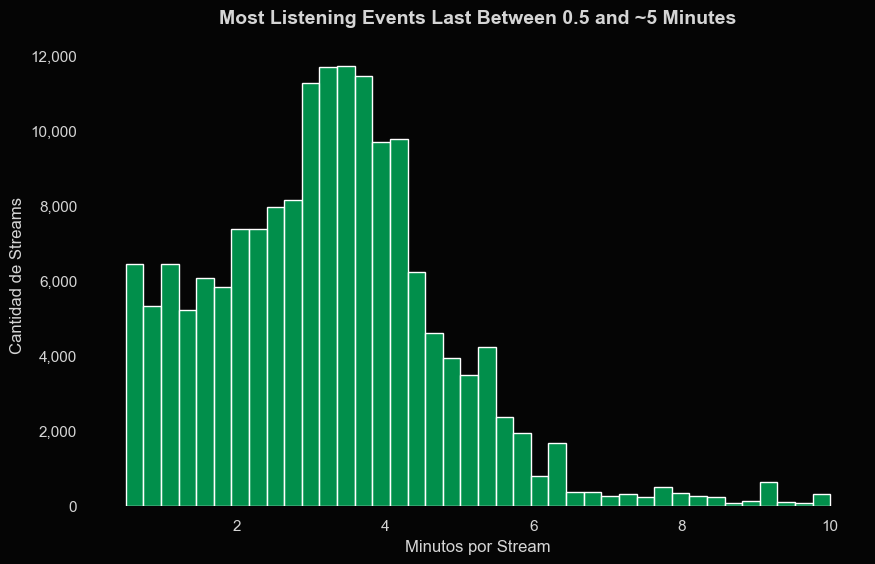

In [95]:
# Filter
df_plot = df_valid[df_valid["minutes_played"] <= 10]

# Colors
bg_color = "#050505"
text_color = "#d5d5d5"
main_color = "#00bf63"

plt.figure(figsize=(10, 6))
ax = plt.gca()

# Background
plt.gcf().patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Plot
sns.histplot(
    df_plot["minutes_played"],
    bins=40,
    color=main_color,
    edgecolor=None
)

# Remove spines
sns.despine(left=True, bottom=True)

# Format ticks with commas
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Labels
ax.set_title(
    "Most Listening Events Last Between 0.5 and ~5 Minutes",
    fontsize=14,
    weight="bold",
    color=text_color,
    pad=15
)

ax.set_xlabel("Minutos por Stream", color=text_color)
ax.set_ylabel("Cantidad de Streams", color=text_color)

# Tick colors
ax.tick_params(colors=text_color)

# Remove grid
plt.grid(False)

plt.show()

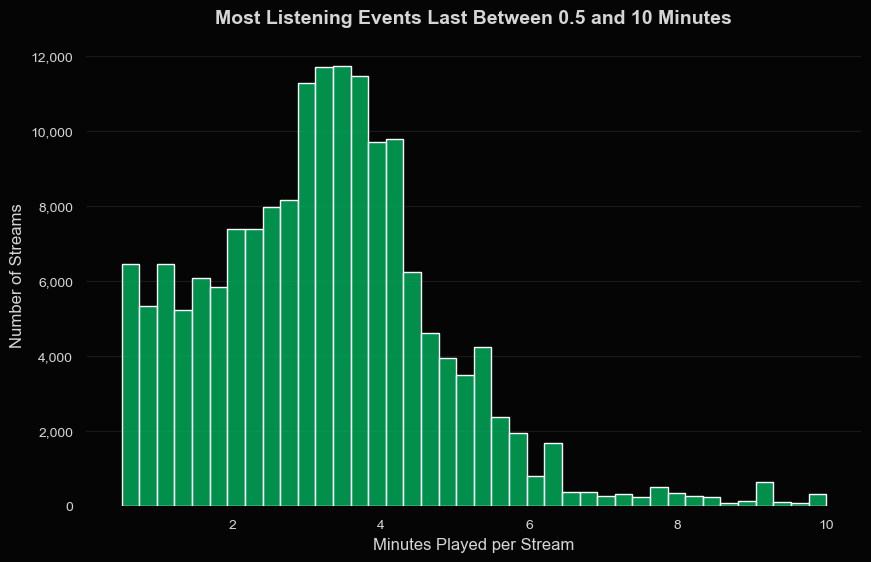

In [94]:
# Filter
df_plot = df_valid[df_valid["minutes_played"] <= 10]

# Colors
bg_color = "#050505"
text_color = "#d5d5d5"
grid_color = "#1a1a1a"   # gris oscuro muy sutil
main_color = "#00bf63"

plt.figure(figsize=(10, 6))
ax = plt.gca()

# Background
plt.gcf().patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Plot
sns.histplot(
    df_plot["minutes_played"],
    bins=40,
    color=main_color,
    edgecolor=None
)

# Subtle grid (solo horizontal, muy tenue)
ax.yaxis.grid(True, color=grid_color, linewidth=0.8)
ax.xaxis.grid(False)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Format ticks with commas
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Labels
ax.set_title(
    "Most Listening Events Last Between 0.5 and 10 Minutes",
    fontsize=14,
    weight="bold",
    color=text_color,
    pad=15
)

ax.set_xlabel("Minutes Played per Stream", color=text_color)
ax.set_ylabel("Number of Streams", color=text_color)

# Tick styling
ax.tick_params(axis='both', colors=text_color, labelsize=10)

plt.show()

In [96]:
mean_val = df_plot["minutes_played"].mean()
median_val = df_plot["minutes_played"].median()

mean_val = round(mean_val, 2)
median_val = round(median_val, 2)

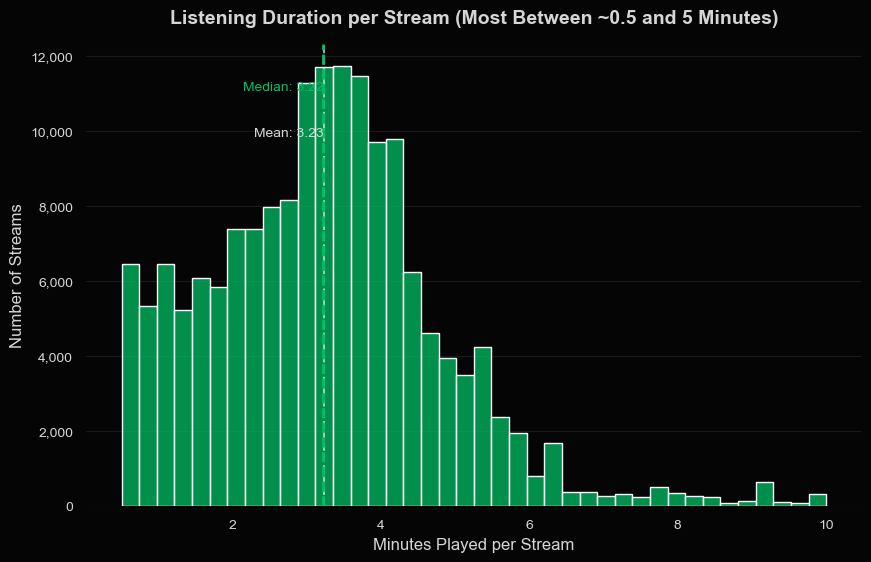

In [99]:
# Filter
df_plot = df_valid[df_valid["minutes_played"] <= 10]

# Stats
mean_val = round(df_plot["minutes_played"].mean(), 2)
#median_val = round(df_plot["minutes_played"].median(), 2)

# Colors
bg_color = "#050505"
text_color = "#d5d5d5"
grid_color = "#1a1a1a"
main_color = "#00bf63"

plt.figure(figsize=(10, 6))
ax = plt.gca()

# Background
plt.gcf().patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Histogram
sns.histplot(
    df_plot["minutes_played"],
    bins=40,
    color=main_color,
    edgecolor=None
)

# Grid (subtle)
ax.yaxis.grid(True, color=grid_color, linewidth=0.8)
ax.xaxis.grid(False)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Format ticks with commas
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Title and labels
ax.set_title(
    "Listening Duration per Stream (Most Between ~0.5 and 5 Minutes)",
    fontsize=14,
    weight="bold",
    color=text_color,
    pad=15
)

ax.set_xlabel("Minutes Played per Stream", color=text_color)
ax.set_ylabel("Number of Streams", color=text_color)

# Tick styling
ax.tick_params(axis='both', colors=text_color, labelsize=10)

# Mean line
ax.axvline(
    mean_val,
    color="#d5d5d5",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

# Median line (recommended)
ax.axvline(
    median_val,
    color=main_color,
    linestyle="--",
    linewidth=2
)

# Annotations
ax.text(
    median_val,
    ax.get_ylim()[1] * 0.9,
    f"Median: {median_val}",
    color=main_color,
    ha="right",
    fontsize=10
)

ax.text(
    mean_val,
    ax.get_ylim()[1] * 0.8,
    f"Mean: {mean_val}",
    color=text_color,
    ha="right",
    fontsize=10
)

plt.show()

In [ ]:
# Base (usamos todo el dataset, no solo valid, porque esto es volumen total)
total_minutes = df["minutes_played"].sum()
total_hours = df["hours_played"].sum()

# Días únicos con actividad
total_days = df["date"].nunique()

# Redondeo
total_minutes = round(total_minutes, 2)
total_hours = round(total_hours, 2)
total_days = round(total_hours/24)

total_minutes, total_hours, total_days

(np.float64(553860.77), np.float64(9231.01), 385)

In [101]:
import pandas as pd

# Asegurar que ts es datetime con timezone UTC
df["ts"] = pd.to_datetime(df["ts"], utc=True)

# Convertir a Guatemala
df["ts_local"] = df["ts"].dt.tz_convert("America/Guatemala")

# Extraer componentes
df["hour_local"] = df["ts_local"].dt.hour
df["date"] = df["ts_local"].dt.date
df["weekday"] = df["ts_local"].dt.day_name()

In [102]:
df[["ts", "ts_local", "hour_local"]].head()

,ts,ts_local,hour_local
0,2017-10-06 03:10:49+00:00,2017-10-05 21:10:49-06:00,21
1,2017-10-06 03:11:09+00:00,2017-10-05 21:11:09-06:00,21
2,2017-10-06 03:12:04+00:00,2017-10-05 21:12:04-06:00,21
3,2017-10-06 03:12:08+00:00,2017-10-05 21:12:08-06:00,21
4,2017-10-06 03:12:13+00:00,2017-10-05 21:12:13-06:00,21


In [103]:
df["day_type"] = df["ts_local"].dt.weekday.map(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

In [104]:
df_valid = df[df["is_valid_stream"]]

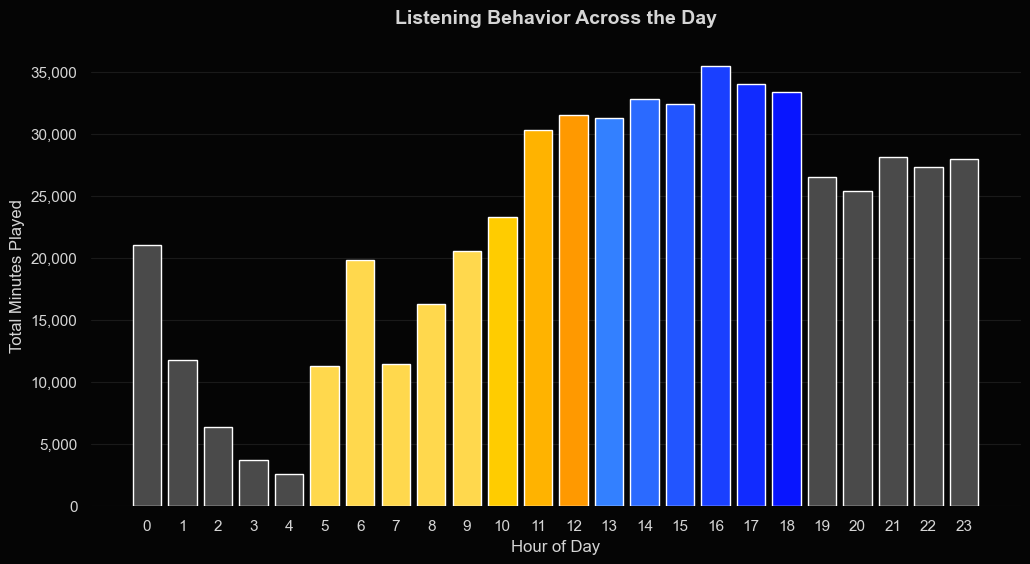

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import numpy as np

# Aggregate
hourly = (
    df_valid
    .groupby("hour_local", as_index=False)
    .agg({"minutes_played": "sum"})
    .sort_values("hour_local")
)

hourly["minutes_played"] = hourly["minutes_played"].round(2)

# Color function
def get_hour_color(hour):
    # Night (7pm–4am)
    if hour >= 19 or hour <= 4:
        return "#4a4a4a"
    
    # Morning (5–9)
    elif 5 <= hour <= 9:
        return "#FFD84D"
    
    # Transition to orange (10–12)
    elif 10 <= hour <= 12:
        # interpolate yellow → orange
        ratio = (hour - 10) / (12 - 10)
        return (1.0, 0.6 + (0.2 * (1 - ratio)), 0.0)
    
    # Afternoon to evening (13–19) → blue gradient
    else:
        ratio = (hour - 13) / (19 - 13)
        return (0.2 * (1 - ratio), 0.5 * (1 - ratio), 1.0)

# Apply colors
colors = [get_hour_color(h) for h in hourly["hour_local"]]

# Colors base
bg_color = "#050505"
text_color = "#d5d5d5"
grid_color = "#1a1a1a"

# Plot
plt.figure(figsize=(12, 6))
ax = plt.gca()

# Background
plt.gcf().patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Bars
bars = ax.bar(
    hourly["hour_local"],
    hourly["minutes_played"],
    color=colors,
    width=0.8
)

# Grid (subtle)
ax.yaxis.grid(True, color=grid_color, linewidth=0.8)
ax.xaxis.grid(False)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Format ticks
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticks(range(0, 24))

# Labels
ax.set_title(
    "Listening Behavior Across the Day",
    fontsize=14,
    weight="bold",
    color=text_color,
    pad=15
)

ax.set_xlabel("Hour of Day", color=text_color)
ax.set_ylabel("Total Minutes Played", color=text_color)

# Tick styling
ax.tick_params(axis='both', colors=text_color)

plt.show()

In [106]:
df_valid = df[df["is_valid_stream"]].copy()

# Extraer año desde ts_local
df_valid["year"] = df_valid["ts_local"].dt.year

In [107]:
hourly_year = (
    df_valid
    .groupby(["year", "hour_local"], as_index=False)
    .agg({"minutes_played": "sum"})
)

# Normalizar por año
hourly_year["pct"] = (
    hourly_year.groupby("year")["minutes_played"]
    .transform(lambda x: x / x.sum())
)

hourly_year["pct"] = hourly_year["pct"].round(4)

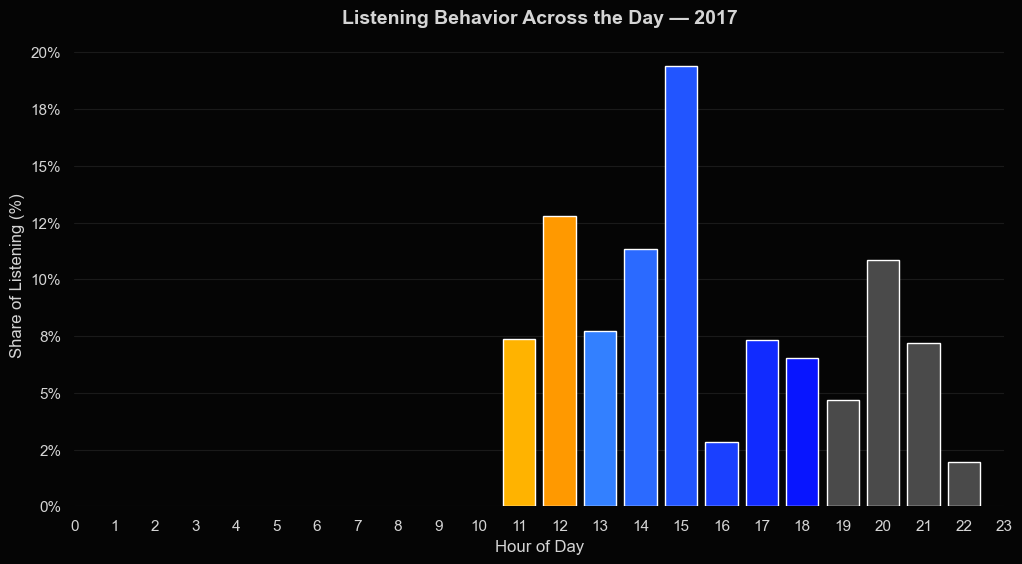

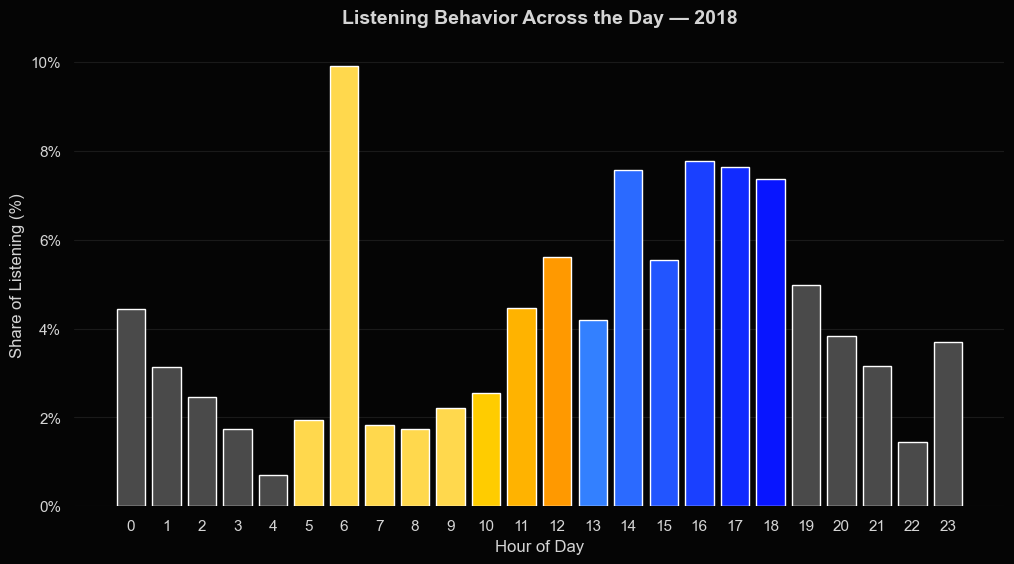

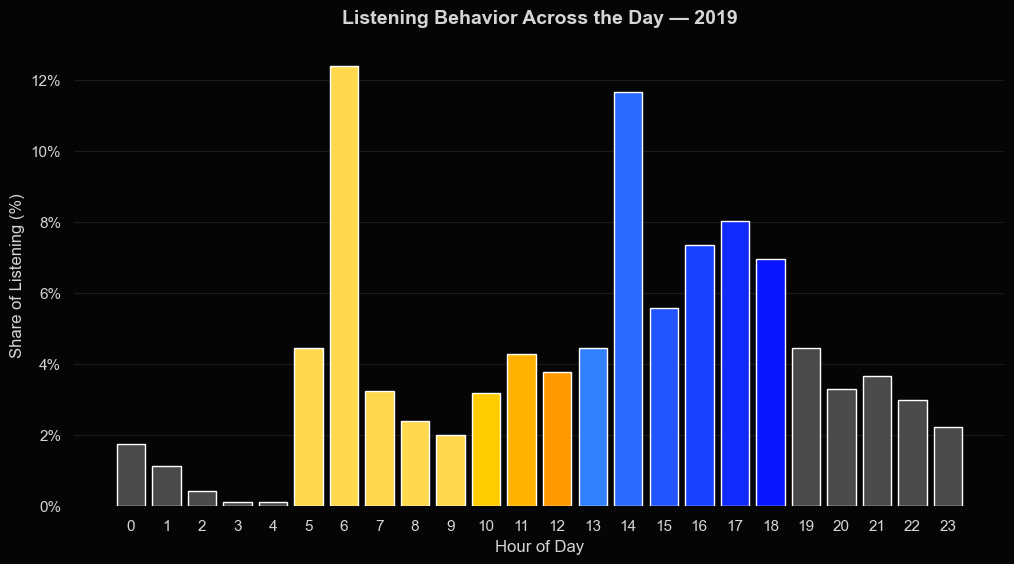

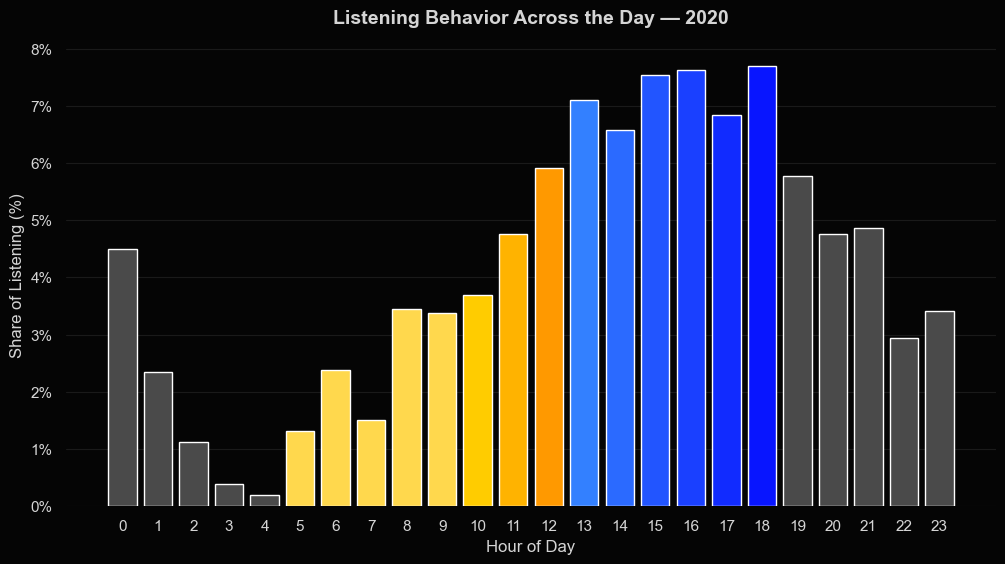

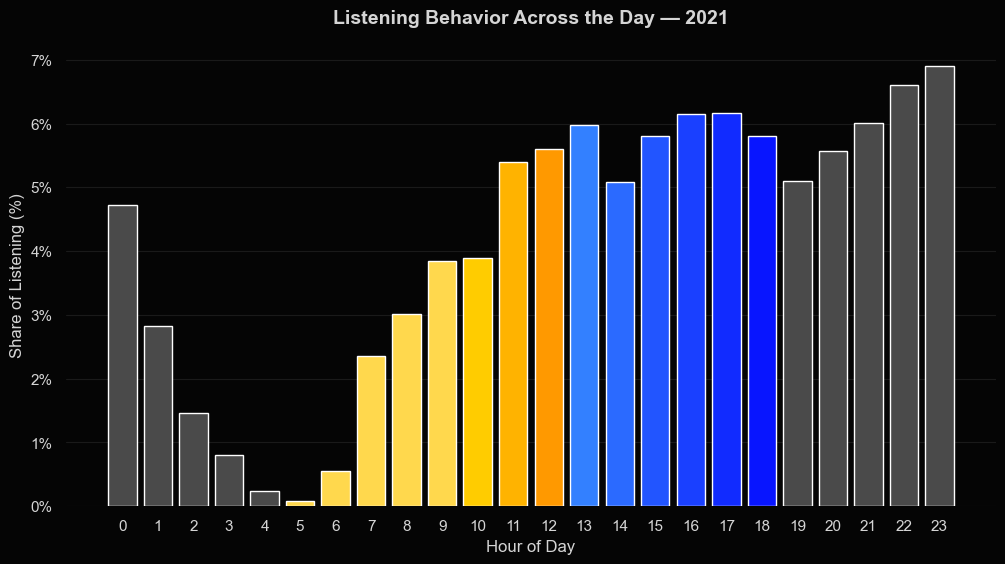

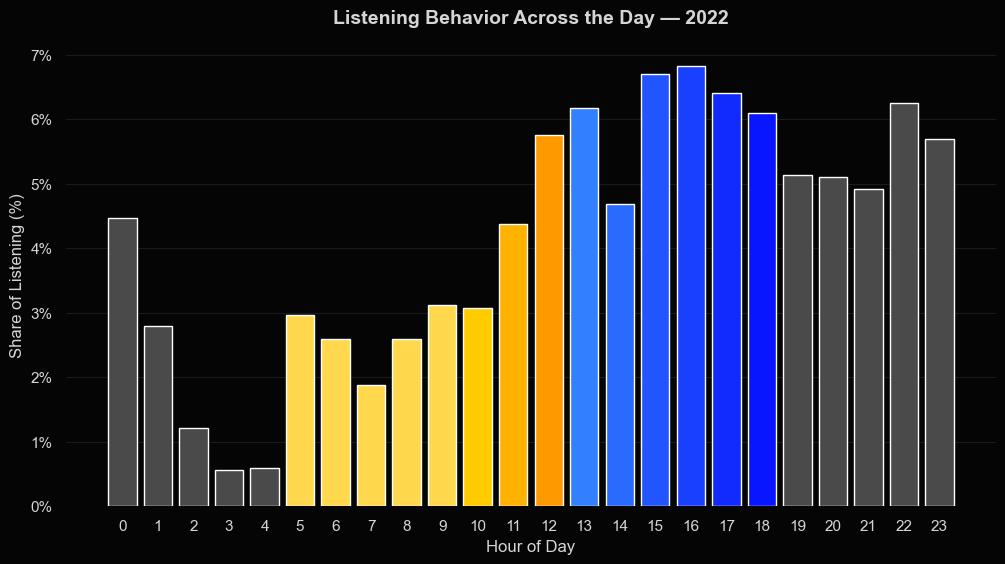

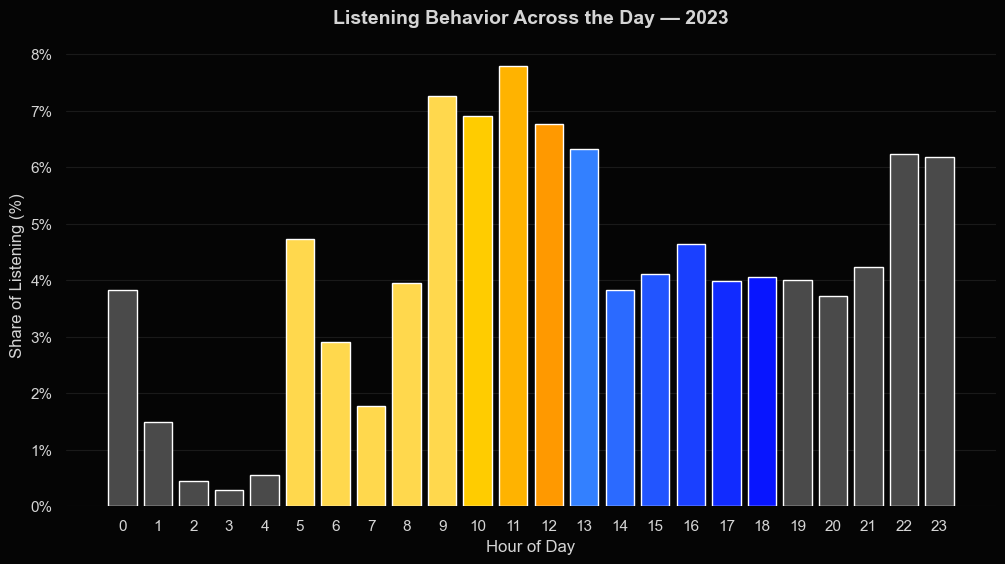

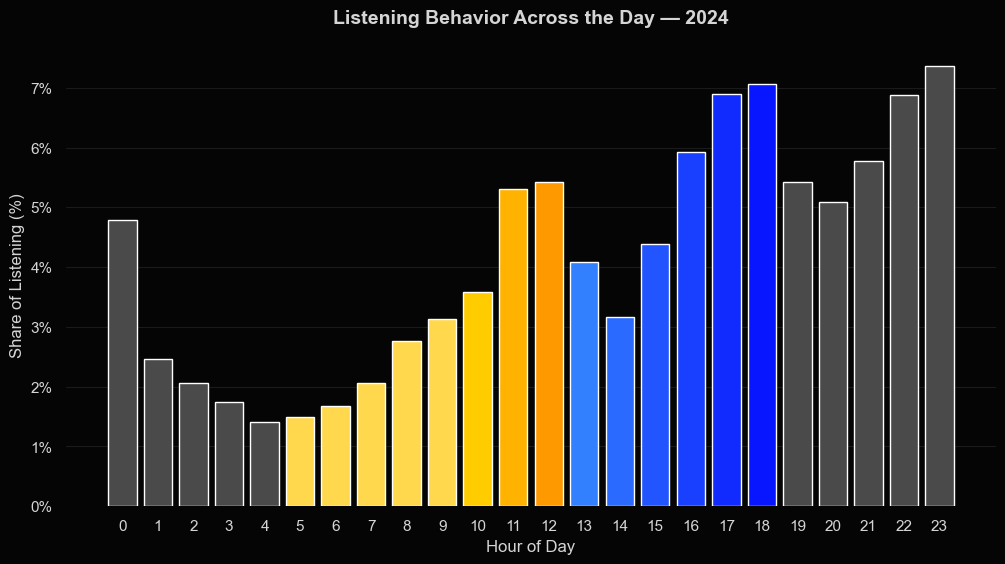

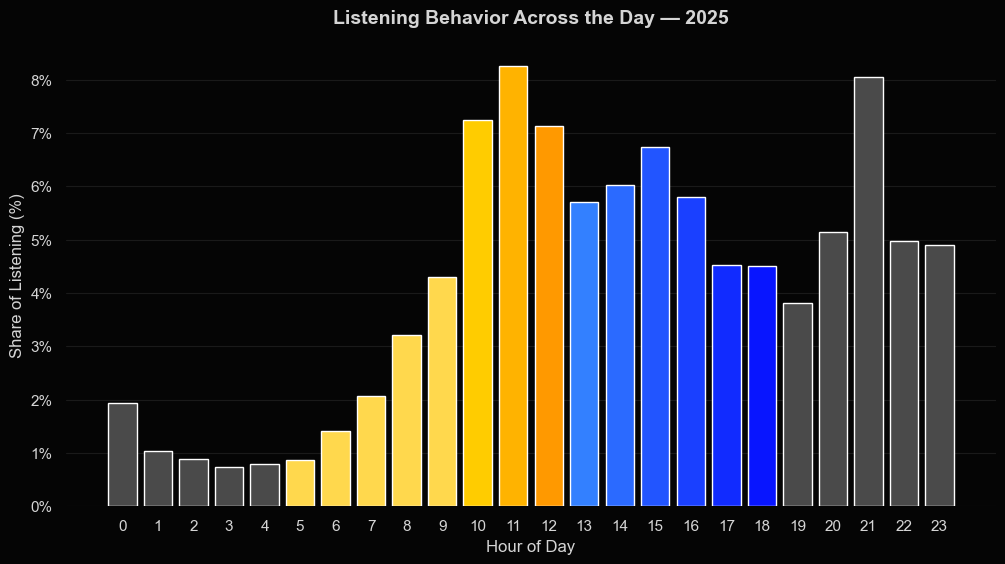

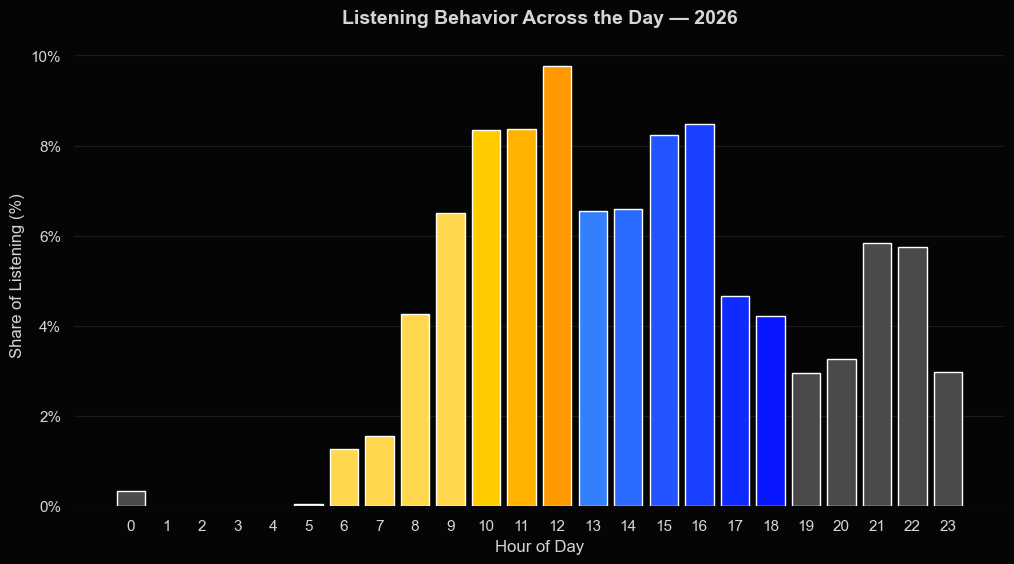

In [108]:
years = sorted(hourly_year["year"].unique())

bg_color = "#050505"
text_color = "#d5d5d5"
grid_color = "#1a1a1a"

for year in years:
    
    df_plot = hourly_year[hourly_year["year"] == year]
    
    colors = [get_hour_color(h) for h in df_plot["hour_local"]]
    
    plt.figure(figsize=(12, 6))
    ax = plt.gca()
    
    # Background
    plt.gcf().patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)
    
    # Bars
    ax.bar(
        df_plot["hour_local"],
        df_plot["pct"],
        color=colors,
        width=0.8
    )
    
    # Grid
    ax.yaxis.grid(True, color=grid_color, linewidth=0.8)
    ax.xaxis.grid(False)
    
    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # Format y-axis as %
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
    
    ax.set_xticks(range(0, 24))
    
    # Titles
    ax.set_title(
        f"Listening Behavior Across the Day — {year}",
        fontsize=14,
        weight="bold",
        color=text_color,
        pad=15
    )
    
    ax.set_xlabel("Hour of Day", color=text_color)
    ax.set_ylabel("Share of Listening (%)", color=text_color)
    
    ax.tick_params(axis='both', colors=text_color)
    
    plt.show()

In [109]:
df_valid = df[df["is_valid_stream"]].copy()

In [110]:
top_tracks = (
    df_valid
    .groupby(
        ["spotify_track_uri",
         "master_metadata_track_name",
         "master_metadata_album_artist_name"],
        as_index=False
    )
    .agg({"minutes_played": "sum"})
    .sort_values("minutes_played", ascending=False)
    .head(10)
)

top_tracks["minutes_played"] = top_tracks["minutes_played"].round(2)

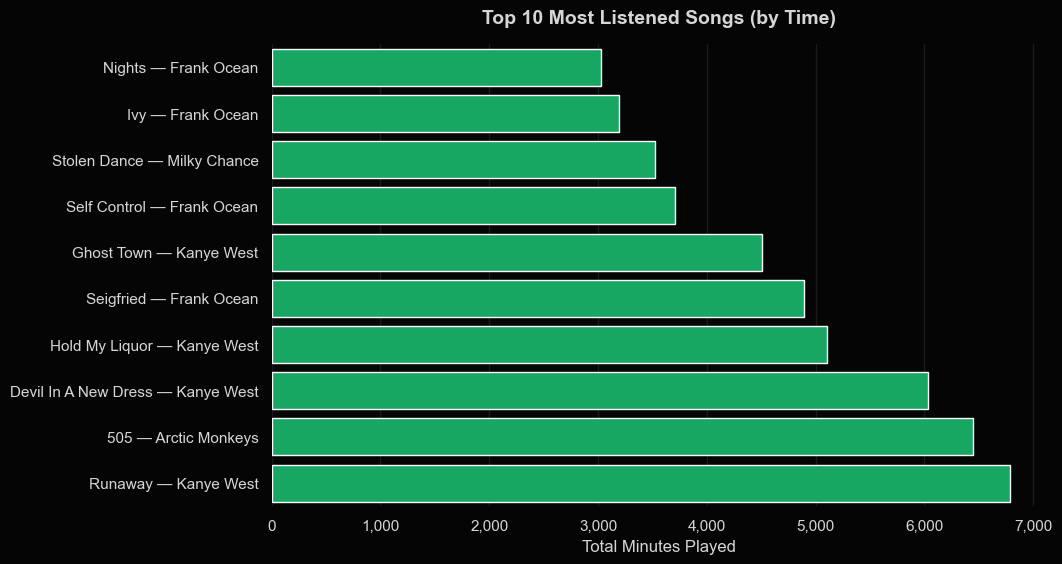

In [111]:
plt.figure(figsize=(10, 6))
ax = plt.gca()

# Background
plt.gcf().patch.set_facecolor("#050505")
ax.set_facecolor("#050505")

# Create label (track + artist)
top_tracks["label"] = (
    top_tracks["master_metadata_track_name"] + " — " +
    top_tracks["master_metadata_album_artist_name"]
)

# Sort for plotting
top_tracks = top_tracks.sort_values("minutes_played", ascending=True)

# Plot
sns.barplot(
    data=top_tracks,
    x="minutes_played",
    y="label",
    color="#00bf63"
)

# Grid (subtle)
ax.xaxis.grid(True, color="#1a1a1a")
ax.yaxis.grid(False)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Format ticks
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Labels
ax.set_title(
    "Top 10 Most Listened Songs (by Time)",
    fontsize=14,
    weight="bold",
    color="#d5d5d5",
    pad=15
)

ax.set_xlabel("Total Minutes Played", color="#d5d5d5")
ax.set_ylabel("")

# Tick styling
ax.tick_params(colors="#d5d5d5")

plt.show()